In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import keras

from matplotlib import pyplot as plt
from keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from keras.applications.resnet50 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from imblearn.over_sampling import SMOTE

In [2]:
BATCH_SIZE = 8
IMG_SIZE = (128, 128)

In [3]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [4]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [5]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [6]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [7]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


In [8]:
train_ds, test_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.8,
    shuffle=True,
    seed=42
)

### BALANCEAMENTO COM SMOTE, DATA AUGMENTATION E RESNET50

Após a divisão entre treino e teste, o SMOTE é aplicado somente ao conjunto de treino, com o objetivo de balancear a quantidade de amostras entre as classes.

Em seguida, o conjunto de treino balanceado é convertido novamente para `tf.data.Dataset`, embaralhado, dividido em batches e submetido ao Data Augmentation durante o treinamento.

O modelo final utiliza a ResNet50 pré-treinada como extratora de características. A camada `Flatten` não é utilizada; no lugar dela, é aplicada a camada `GlobalAveragePooling2D`, reduzindo a quantidade de parâmetros antes das camadas densas.


In [9]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels


In [10]:

def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for image, label in ds:
        images_list.append(image.numpy().astype("float32"))
        labels_list.append(label.numpy())

    X = np.stack(images_list)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

X_train, y_train = dataset_to_numpy(train_ds)

In [11]:
print("Distribuição original do treino:")
print(Counter(y_train))

Distribuição original do treino:
Counter({np.int32(1): 5349, np.int32(4): 901, np.int32(0): 873, np.int32(2): 422, np.int32(3): 262, np.int32(6): 116, np.int32(5): 89})


In [12]:
original_train_label_counts = pd.Series(y_train).value_counts().sort_index()
original_train_label_counts.index = [class_name[i] for i in original_train_label_counts.index]

n_samples, height, width, channels = X_train.shape

X_train_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_smote_flat, y_train_smote = smote.fit_resample(
    X_train_flat,
    y_train
)

X_train_smote = X_train_smote_flat.reshape(-1, height, width, channels)
X_train_smote = np.clip(X_train_smote, 0, 255).astype("float32")
y_train_smote = y_train_smote.astype("int32")

In [13]:
print("\nDistribuição do treino após SMOTE:")
print(Counter(y_train_smote))


Distribuição do treino após SMOTE:
Counter({np.int32(1): 5349, np.int32(2): 5349, np.int32(4): 5349, np.int32(0): 5349, np.int32(5): 5349, np.int32(3): 5349, np.int32(6): 5349})


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_smote, y_train_smote))

train_ds = train_ds.shuffle(
    buffer_size=len(y_train_smote),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

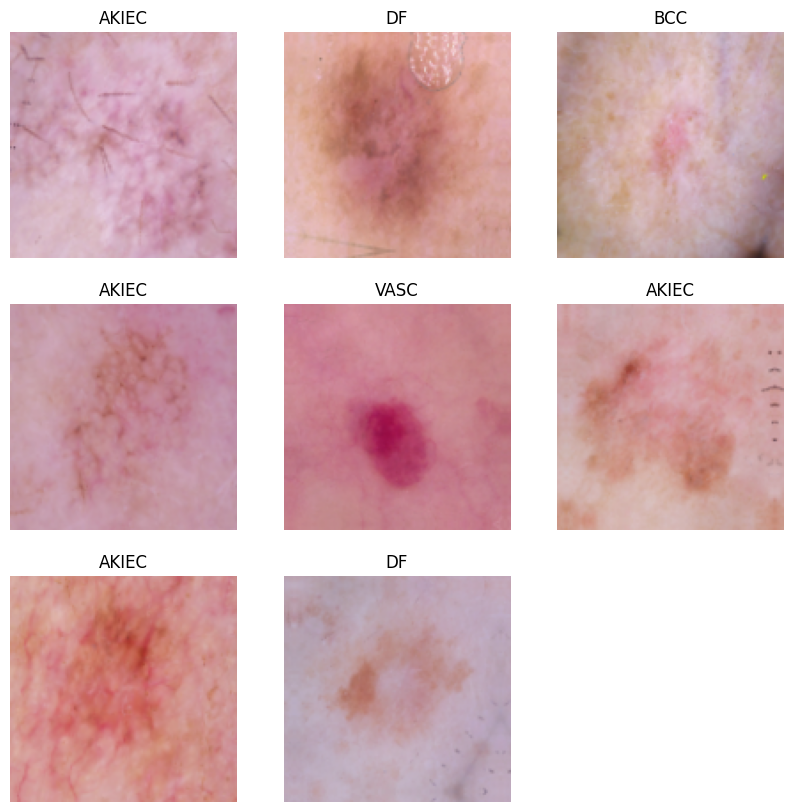

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino após SMOTE: 37443


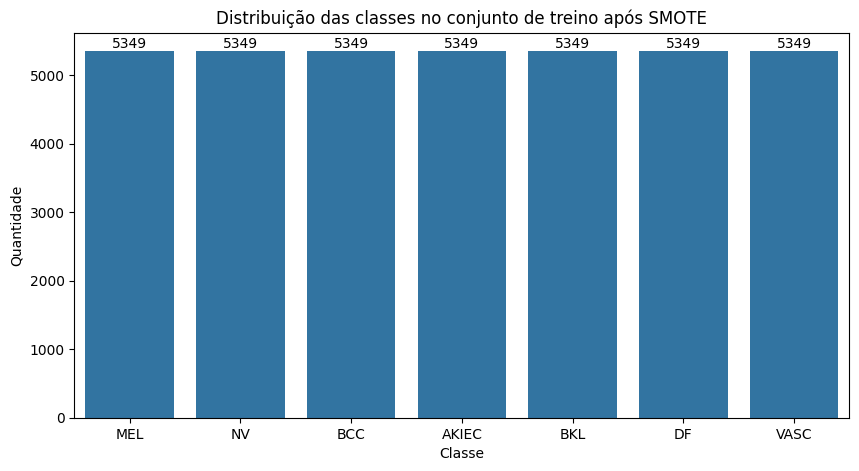

MEL      5349.0
NV       5349.0
BCC      5349.0
AKIEC    5349.0
BKL      5349.0
DF       5349.0
VASC     5349.0
dtype: object


In [16]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)

print("Quantidade de imagens no conjunto de treino após SMOTE:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino após SMOTE")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [17]:
# Modelo com ResNet50 pré-treinada no ImageNet
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Congela a base convolucional para usar a ResNet50 como extratora de características
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(classes))(x)

model = models.Model(inputs=inputs, outputs=outputs, name="cnn_resnet50")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "cnn_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │        903 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [19]:
print("Distribuição final usada no treinamento:")
print(label_counts)

Distribuição final usada no treinamento:
MEL      5349.0
NV       5349.0
BCC      5349.0
AKIEC    5349.0
BKL      5349.0
DF       5349.0
VASC     5349.0
dtype: object


In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [21]:
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Epoch 1/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 353s 75ms/step - accuracy: 0.6084 - loss: 1.2615 - val_accuracy: 0.6635 - val_loss: 0.9804
Epoch 2/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 413s 88ms/step - accuracy: 0.7251 - loss: 0.8775 - val_accuracy: 0.6630 - val_loss: 0.9811
Epoch 3/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 367s 78ms/step - accuracy: 0.7604 - loss: 0.7626 - val_accuracy: 0.6855 - val_loss: 0.8861
Epoch 4/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 357s 76ms/step - accuracy: 0.7834 - loss: 0.6970 - val_accuracy: 0.7029 - val_loss: 0.8473
Epoch 5/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 367s 78ms/step - accuracy: 0.7974 - loss: 0.6517 - val_accuracy: 0.6670 - val_loss: 0.9358
Epoch 6/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 368s 79ms/step - accuracy: 0.8099 - loss: 0.6189 - val_accuracy: 0.7209 - val_loss: 0.8286
Epoch 7/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 392s 84ms/step - accuracy: 0.8184 - loss: 0.5940 - val_accuracy: 0.7299 - val_loss: 0.8301
Epoch 8/200
4681/4681 ━━━━━━━━━━━━━━━━━━━━ 366s 78ms/step - ac

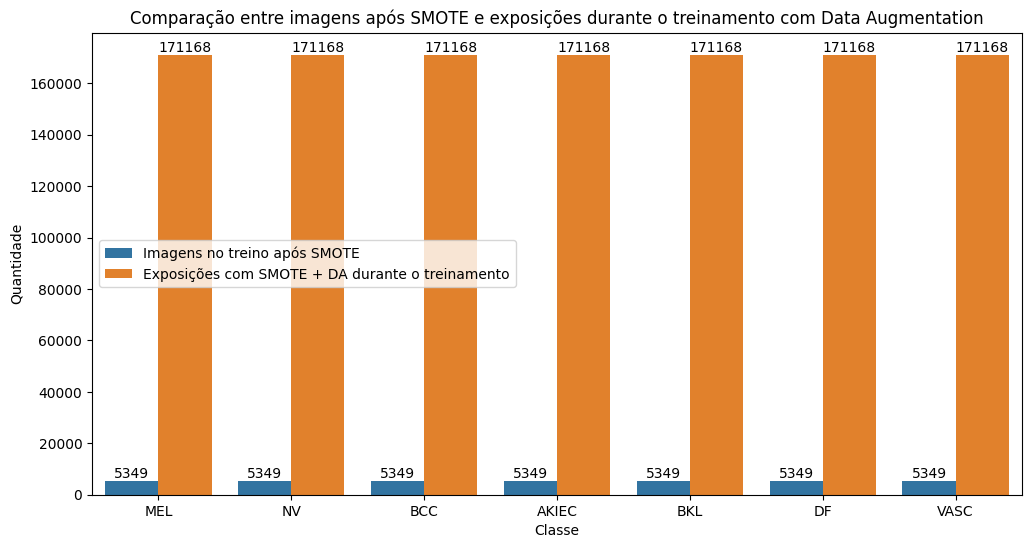

In [22]:
epochs = len(history.history["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index.tolist(),
    "Imagens no treino após SMOTE": label_counts.values,
    "Exposições com SMOTE + DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens após SMOTE e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()

In [23]:
"history" in globals()

True

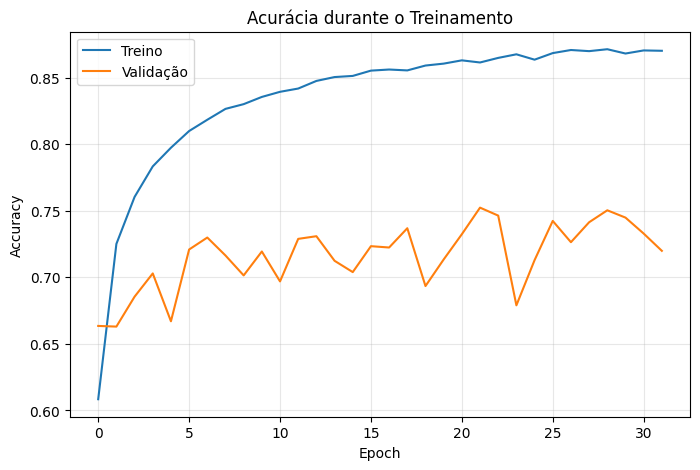

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

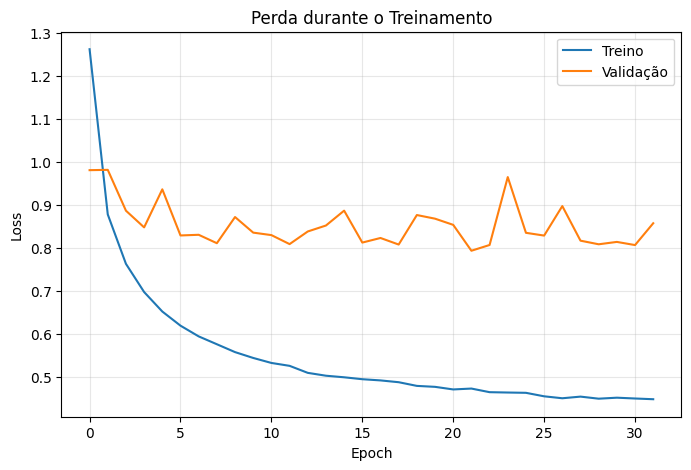

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])

In [27]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

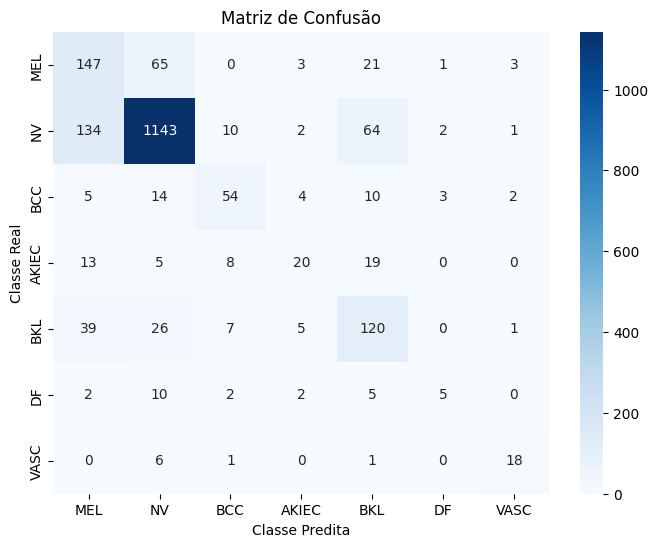

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [29]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.4324    0.6125    0.5069       240
          NV     0.9007    0.8429    0.8709      1356
         BCC     0.6585    0.5870    0.6207        92
       AKIEC     0.5556    0.3077    0.3960        65
         BKL     0.5000    0.6061    0.5479       198
          DF     0.4545    0.1923    0.2703        26
        VASC     0.7200    0.6923    0.7059        26

    accuracy                         0.7524      2003
   macro avg     0.6031    0.5487    0.5598      2003
weighted avg     0.7745    0.7524    0.7585      2003



In [30]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7524

Macro Average:
  Precision: 0.6031
  Recall: 0.5487
  F1-Score: 0.5598

Weighted Average:
  Precision: 0.7745
  Recall: 0.7524
  F1-Score: 0.7585


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


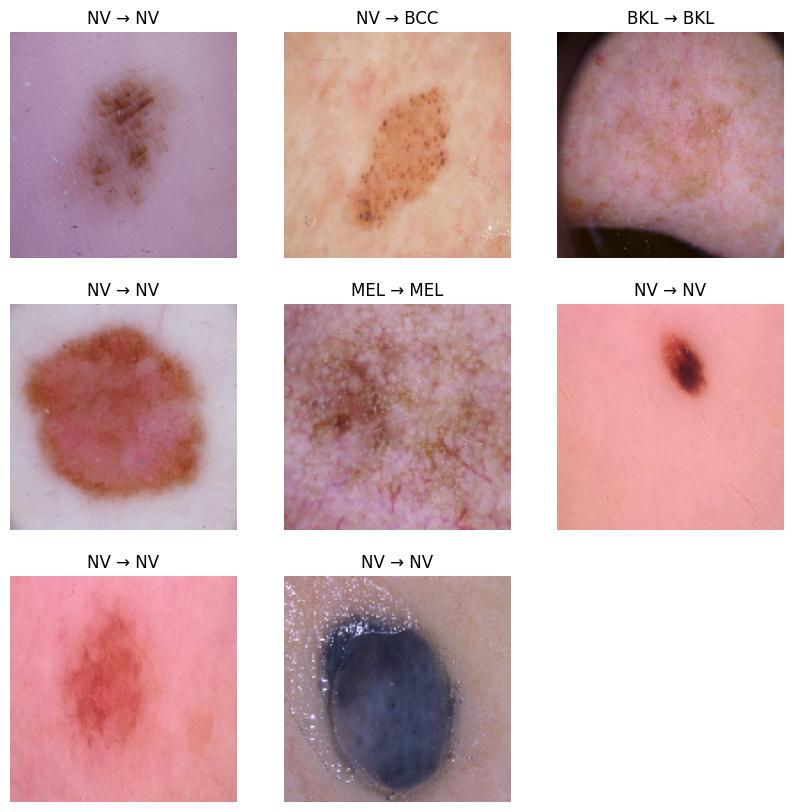

In [31]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [32]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nDiagnóstico final:")
print(f"Train accuracy: {final_train_acc:.4f}")
print(f"Val accuracy: {final_val_acc:.4f}")
print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss: {final_val_loss:.4f}")


Diagnóstico final:
Train accuracy: 0.8702
Val accuracy: 0.7199
Train loss: 0.4479
Val loss: 0.8570
